# L2.4 — Bias / Variance Trade-off

Hands-on notebook for the lesson [`2-4-bias-variance.mdx`](../../llm-quest-theory/level-2/2-4-bias-variance.mdx).

> **Learning objectives**
> - Fit polynomial regressions of increasing degree on the same data and watch bias → variance.
> - Plot the classic U-shaped test error curve vs model complexity.
> - Empirically estimate bias^2, variance, and irreducible noise via bootstrap resampling.
> - Read a complexity-aware learning curve.

## Connection to the theory
Covers **§1–§6** of the source `.mdx`. This is the notebook that makes the phrase "overfitting" feel visceral.

In [1]:
# ---- Setup ----
import warnings
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

warnings.filterwarnings("ignore", category=UserWarning)
from scipy.linalg import LinAlgWarning
warnings.filterwarnings("ignore", category=LinAlgWarning)
SEED = 42
np.random.seed(SEED)
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

## 1. A simple nonlinear target
`f_true(x) = sin(1.5 x) + 0.3 x`. We sample 50 noisy points.

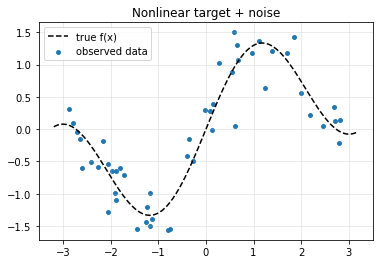

In [2]:
def f_true(x):
    return np.sin(1.5 * x) + 0.3 * x

N = 50
noise_sigma = 0.35
x_all = np.sort(np.random.uniform(-3, 3, size=N))
y_all = f_true(x_all) + np.random.normal(0, noise_sigma, size=N)

x_grid = np.linspace(-3.2, 3.2, 300)
fig, ax = plt.subplots()
ax.plot(x_grid, f_true(x_grid), "k--", label="true f(x)")
ax.scatter(x_all, y_all, s=15, label="observed data")
ax.grid(alpha=0.3); ax.legend(); ax.set_title("Nonlinear target + noise")
plt.show()

## 2. Three polynomial fits — underfit, just right, overfit
Same data, polynomial degree 1 / 4 / 15. Note how the high-degree curve wiggles between data points.

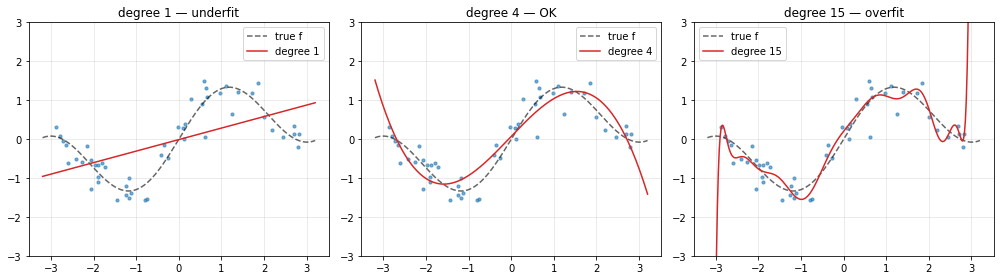

In [3]:
def fit_poly(x, y, degree):
    # Ridge with tiny alpha keeps high-degree fits numerically stable
    model = make_pipeline(PolynomialFeatures(degree, include_bias=False),
                          Ridge(alpha=1e-8))
    model.fit(x.reshape(-1, 1), y)
    return model

degrees_show = [1, 4, 15]
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, d in zip(axes, degrees_show):
    m = fit_poly(x_all, y_all, d)
    ax.plot(x_grid, f_true(x_grid), "k--", alpha=0.6, label="true f")
    ax.plot(x_grid, m.predict(x_grid.reshape(-1, 1)), "tab:red", label=f"degree {d}")
    ax.scatter(x_all, y_all, s=10, alpha=0.6)
    ax.set_ylim(-3, 3); ax.grid(alpha=0.3); ax.legend()
    ax.set_title(f"degree {d} — {'underfit' if d == 1 else 'OK' if d == 4 else 'overfit'}")
plt.tight_layout(); plt.show()

## 3. The U-shaped test error
Sweep the polynomial degree and record train/test MSE on a single random split.

best-test degree on this split: 7  (test MSE = 0.091)


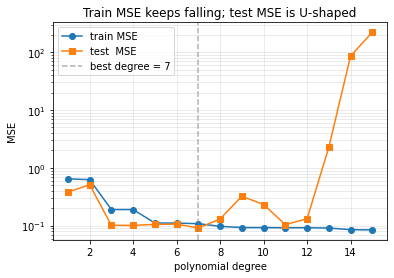

In [4]:
x_tr, x_te, y_tr, y_te = train_test_split(x_all, y_all, test_size=0.4, random_state=SEED)

degrees = range(1, 16)
train_mse, test_mse = [], []
for d in degrees:
    m = fit_poly(x_tr, y_tr, d)
    train_mse.append(mean_squared_error(y_tr, m.predict(x_tr.reshape(-1, 1))))
    test_mse.append( mean_squared_error(y_te, m.predict(x_te.reshape(-1, 1))))

best_d = int(np.argmin(test_mse)) + 1
print(f"best-test degree on this split: {best_d}  (test MSE = {min(test_mse):.3f})")

fig, ax = plt.subplots()
ax.plot(list(degrees), train_mse, "o-", label="train MSE")
ax.plot(list(degrees), test_mse,  "s-", label="test  MSE")
ax.axvline(best_d, linestyle="--", color="gray", alpha=0.6, label=f"best degree = {best_d}")
ax.set_xlabel("polynomial degree"); ax.set_ylabel("MSE")
ax.set_yscale("log"); ax.grid(alpha=0.3, which="both"); ax.legend()
ax.set_title("Train MSE keeps falling; test MSE is U-shaped")
plt.show()

## 4. Bootstrap-estimated bias, variance, noise
Classic decomposition: at a fixed point `x*`, the expected squared error of `\hat f(x*)` over random training sets is

$$\mathbb{E}[(\hat f(x^*) - y^*)^2] = \underbrace{(\mathbb{E}[\hat f(x^*)] - f_{\text{true}}(x^*))^2}_{\text{bias}^2} + \underbrace{\mathrm{Var}(\hat f(x^*))}_{\text{variance}} + \underbrace{\sigma^2}_{\text{noise}}$$

We approximate `E` / `Var` by training many bootstrap resamples and looking at the predictions on a fixed evaluation grid.

In [5]:
# We decompose bias/variance by sampling many *fresh* training sets from the data-generator.
# (Bootstrap from a small fixed set tends to blow up for high-degree polynomials.)
n_samples_for_decomp = 100
# Evaluate in the interior to avoid polynomial blow-up near the boundary.
x_eval = np.linspace(-2.5, 2.5, 100)

def sample_dataset(rng, size=50, sigma=noise_sigma):
    x = np.sort(rng.uniform(-3, 3, size=size))
    y = f_true(x) + rng.normal(0, sigma, size=size)
    return x, y

# Slightly stronger ridge keeps the high-degree bootstraps sane:
def fit_poly_decomp(x, y, degree, alpha=0.1):
    m = make_pipeline(PolynomialFeatures(degree, include_bias=False), Ridge(alpha=alpha))
    m.fit(x.reshape(-1, 1), y)
    return m

def bias_var_decomposition(degree, n=n_samples_for_decomp, sigma2=noise_sigma ** 2):
    rng = np.random.default_rng(SEED + degree)
    preds = np.zeros((n, len(x_eval)))
    for b in range(n):
        x_b, y_b = sample_dataset(rng, size=N)
        preds[b] = fit_poly_decomp(x_b, y_b, degree).predict(x_eval.reshape(-1, 1))
    mean_pred = preds.mean(axis=0)
    bias2 = float(np.mean((mean_pred - f_true(x_eval)) ** 2))
    var   = float(np.mean(preds.var(axis=0)))
    return bias2, var, sigma2

table = []
for d in [1, 2, 4, 6, 8, 10]:
    b2, v, n = bias_var_decomposition(d)
    table.append((d, b2, v, n, b2 + v + n))
    print(f"degree {d:>2}  bias^2={b2:.3f}  var={v:.3f}  noise={n:.3f}  total={b2+v+n:.3f}")

degree  1  bias^2=0.443  var=0.027  noise=0.122  total=0.592
degree  2  bias^2=0.424  var=0.029  noise=0.122  total=0.576
degree  4  bias^2=0.055  var=0.018  noise=0.122  total=0.196
degree  6  bias^2=0.001  var=0.016  noise=0.122  total=0.140
degree  8  bias^2=0.000  var=0.019  noise=0.122  total=0.142
degree 10  bias^2=0.001  var=0.023  noise=0.122  total=0.146


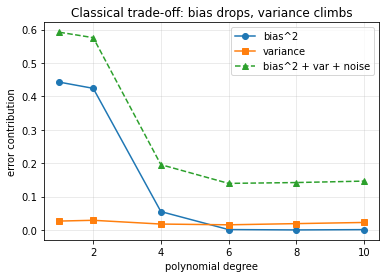

In [6]:
ds    = [row[0] for row in table]
bias2 = [row[1] for row in table]
vars_ = [row[2] for row in table]
total = [row[4] for row in table]

fig, ax = plt.subplots()
ax.plot(ds, bias2, "o-", label="bias^2")
ax.plot(ds, vars_, "s-", label="variance")
ax.plot(ds, total, "^--", label="bias^2 + var + noise")
ax.set_xlabel("polynomial degree"); ax.set_ylabel("error contribution")
ax.grid(alpha=0.3); ax.legend()
ax.set_title("Classical trade-off: bias drops, variance climbs")
plt.show()

## 5. Learning curve at low vs high complexity
How does each model class use extra data?

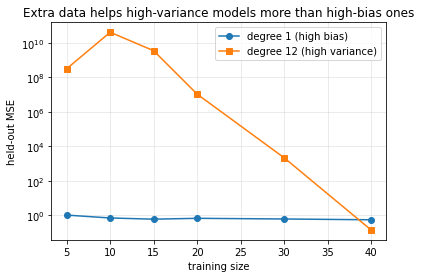

In [7]:
def learning_curve_manual(degree, sizes, rng):
    out = []
    for n in sizes:
        errs = []
        for _ in range(20):  # average a few resamples
            idx = rng.choice(N, size=n, replace=False)
            x_sub, y_sub = x_all[idx], y_all[idx]
            m = fit_poly(x_sub, y_sub, degree)
            # Evaluate on a held-out set: the rest of the data
            hold = np.setdiff1d(np.arange(N), idx)
            errs.append(mean_squared_error(y_all[hold], m.predict(x_all[hold].reshape(-1, 1))))
        out.append(np.mean(errs))
    return np.array(out)

rng = np.random.default_rng(SEED)
sizes = [5, 10, 15, 20, 30, 40]
curve_lo = learning_curve_manual(1,  sizes, rng)
curve_hi = learning_curve_manual(12, sizes, rng)

fig, ax = plt.subplots()
ax.plot(sizes, curve_lo, "o-", label="degree 1 (high bias)")
ax.plot(sizes, curve_hi, "s-", label="degree 12 (high variance)")
ax.set_xlabel("training size"); ax.set_ylabel("held-out MSE")
ax.set_yscale("log"); ax.grid(alpha=0.3, which="both"); ax.legend()
ax.set_title("Extra data helps high-variance models more than high-bias ones")
plt.show()

## 6. Quick checks

In [8]:
# Training MSE should drop monotonically as we add parameters
assert train_mse[-1] <= train_mse[0], "training MSE should not increase with degree"
# Test MSE should be U-shaped: the last degree is worse than the best
assert test_mse[best_d - 1] <= test_mse[-1],  "high-degree should overfit eventually"
# Bias should drop substantially as capacity grows
assert bias2[0] - bias2[-1] > 0.1, "bias should shrink meaningfully with capacity"
# (Variance trend depends on N vs degree; we do not assert monotonicity here.)
print("OK — bias / variance trade-off shows up as expected.")

OK — bias / variance trade-off shows up as expected.


## Reflection questions

1. The bootstrap estimate of `bias^2 + variance + noise` should approximate the expected test error. In section 4, is the sum anywhere near the test MSE for the same degree?
2. "Double descent" says that in massive models, test error can start falling again beyond the classical overfitting point. Why would that not show up in the plot in section 3?
3. Your learning curve plateaus far above 0. What two things could make it drop — more data, or more model capacity? How would you tell which one you need?
4. Why is ridge (`alpha`) a knob for trading bias against variance? Predict what happens if you raise `alpha` on the degree-15 fit.

## References
- Source theory: [`2-4-bias-variance.mdx`](../../llm-quest-theory/level-2/2-4-bias-variance.mdx)
- Next: [`2-5-churn-boss`](2-5-churn-boss.ipynb) — the Level 2 boss.